In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('data/metrics.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')
df.describe()

Loaded 54039 rows, 4 columns


,timestamp,cpu_percent,ram_percent,disk_percent
count,54039,54039.000000,54039.000000,54039.000000
mean,2026-05-17 01:20:04.853790976,4.110283,82.863160,24.321303
min,2026-05-15 12:26:56,0.000000,20.400000,22.300000
25%,2026-05-16 14:27:34,0.800000,75.800000,22.800000
50%,2026-05-16 21:37:42,3.500000,86.800000,25.300000
75%,2026-05-17 12:23:25.500000,4.500000,92.500000,25.400000
max,2026-05-17 15:05:01,84.900000,98.000000,25.500000
std,NaN,5.860895,12.125186,1.280809


In [21]:
df = df[(df['cpu_percent'] > 0) & (df['ram_percent'] > 0)]
df = df.drop_duplicates(subset='timestamp')
print(f'Clean rows: {len(df)}')

Clean rows: 30338


In [22]:
df.describe()

,timestamp,cpu_percent,ram_percent,disk_percent
count,30338,30338.000000,30338.000000,30338.000000
mean,2026-05-17 01:42:32.291548416,3.378822,80.666072,24.316079
min,2026-05-15 12:26:56,0.300000,20.400000,22.300000
25%,2026-05-16 14:23:32.249999872,0.800000,74.600000,22.800000
50%,2026-05-16 21:35:34.500000,3.300000,84.800000,25.300000
75%,2026-05-17 12:24:59.750000128,4.300000,91.800000,25.400000
max,2026-05-17 15:05:01,84.900000,97.800000,25.500000
std,NaN,4.618268,13.028570,1.286442


In [23]:
len(df)

30338

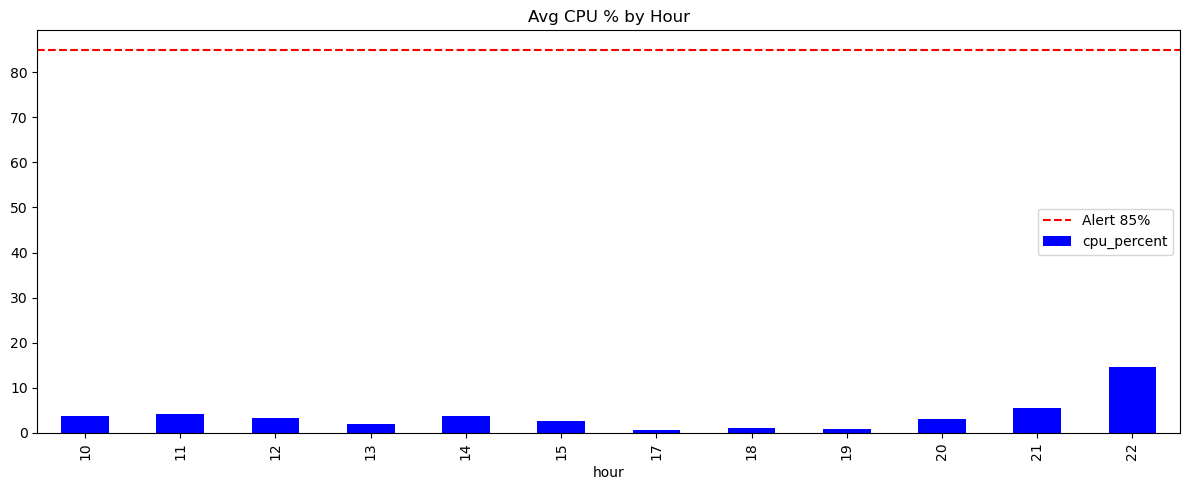

In [24]:
df['hour'] = df['timestamp'].dt.hour
hourly = df.groupby('hour')['cpu_percent'].mean()
hourly.plot(kind='bar', title='Avg CPU % by Hour', color='Blue', figsize=(12,5))
plt.axhline(y=85, color='red', linestyle='--', label='Alert 85%')
plt.legend(); plt.tight_layout()
plt.savefig('cpu_by_hour.png'); plt.show()

In [25]:
summary = df.groupby(df['timestamp'].dt.date).agg(
    avg_cpu  = ('cpu_percent', 'mean'),
    max_cpu  = ('cpu_percent', 'max'),
    avg_ram  = ('ram_percent', 'mean'),
    max_disk = ('disk_percent', 'max')
).reset_index()
summary.to_excel('daily_summary.xlsx', index=False)
print('Exported to daily_summary.xlsx')

Exported to daily_summary.xlsx


In [26]:
import sqlite3
conn = sqlite3.connect('data/metrics.db')

In [27]:
# Query 1: Average CPU per hour
q1 = '''SELECT strftime('%H', timestamp) AS hour,
               ROUND(AVG(cpu_percent), 2) AS avg_cpu
        FROM metrics GROUP BY hour ORDER BY hour'''
pd.read_sql(q1, conn)

,hour,avg_cpu
0,10,3.70
1,11,4.40
2,12,3.96
3,13,1.77
4,14,4.11
5,15,1.90
6,17,0.57
7,18,1.05
8,19,0.66
9,20,2.78


In [28]:
# Query 2: Top 10 high CPU events
q2 = '''SELECT * FROM metrics WHERE cpu_percent > 80
        ORDER BY timestamp DESC LIMIT 10'''
pd.read_sql(q2, conn)

,timestamp,cpu_percent,ram_percent,disk_percent
0,2026-05-17 15:00:02,84.9,92.0,25.5
1,2026-05-17 15:00:02,84.5,92.0,25.5
2,2026-05-17 14:00:03,80.6,89.7,25.5


In [29]:
# Query 3: Daily aggregated summary
q3 = '''SELECT DATE(timestamp) AS day, COUNT(*) AS total_readings,
               ROUND(AVG(cpu_percent),1) AS avg_cpu,
               MAX(disk_percent) AS max_disk
        FROM metrics GROUP BY DATE(timestamp) ORDER BY day DESC'''
pd.read_sql(q3, conn)

,day,total_readings,avg_cpu,max_disk
0,2026-05-17,22393,4.7,25.5
1,2026-05-16,30974,3.7,25.5
2,2026-05-15,21,0.5,22.8


In [30]:
df.to_csv('cleaned_metrics.csv', index=False)